<a href="https://colab.research.google.com/github/Varun01171/Data-Analytics-Projects-UNI/blob/main/Copy_of_Mini_Project_End_to_End_Analytics_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('HR_comma_sep.csv')

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.10,0.77,6,247,4,0,1,0,sales,low
3,0.92,0.85,5,259,5,0,1,0,sales,low
4,0.89,1.00,5,224,5,0,1,0,sales,low


In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (14995, 10)

Columns:
 Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

Data Types:
 satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object


In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)

Shape: (14995, 10)

Columns:
 Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

Data Types:
 satisfaction_level       float64
last_evaluation          float64
number_project             int64
average_montly_hours       int64
time_spend_company         int64
Work_accident              int64
left                       int64
promotion_last_5years      int64
Department                object
salary                    object
dtype: object


In [ ]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64


In [ ]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident', 'left',
       'promotion_last_5years', 'Department', 'salary'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Encode salary (always present)
df['salary'] = le.fit_transform(df['salary'])

# Handle department column (name may vary)
if 'sales' in df.columns:
    df['sales'] = le.fit_transform(df['sales'])
elif 'Department' in df.columns:
    df['Department'] = le.fit_transform(df['Department'])

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('left', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
count,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000,14995.000000
mean,0.612890,0.716108,3.803001,201.050150,3.498166,0.144648,0.237879,0.021274,5.870223,1.347316
std,0.248615,0.171166,1.232266,49.943356,1.460262,0.351758,0.425799,0.144300,2.869110,0.625861
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000,4.000000,1.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000,7.000000,1.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000,8.000000,2.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000,9.000000,2.000000


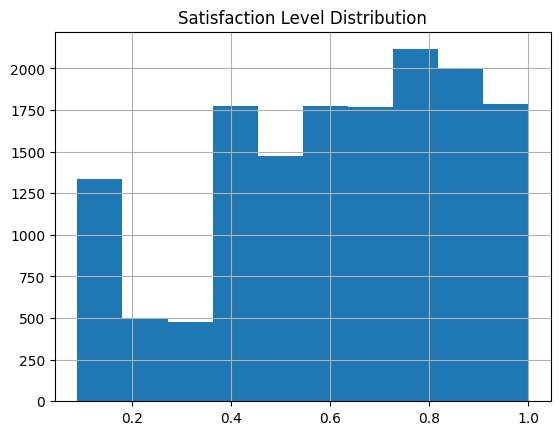

In [ ]:
df['satisfaction_level'].hist()
plt.title("Satisfaction Level Distribution")
plt.show()

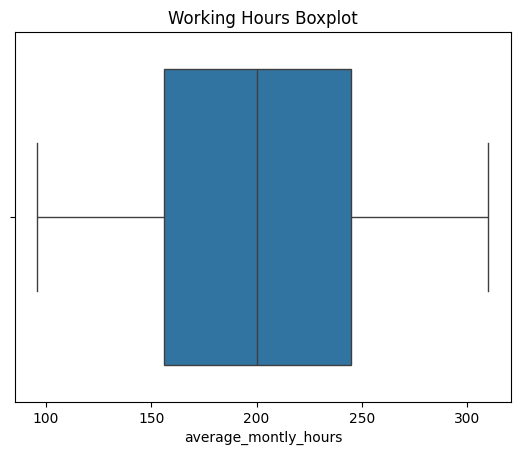

In [ ]:
sns.boxplot(x=df['average_montly_hours'])
plt.title("Working Hours Boxplot")
plt.show()

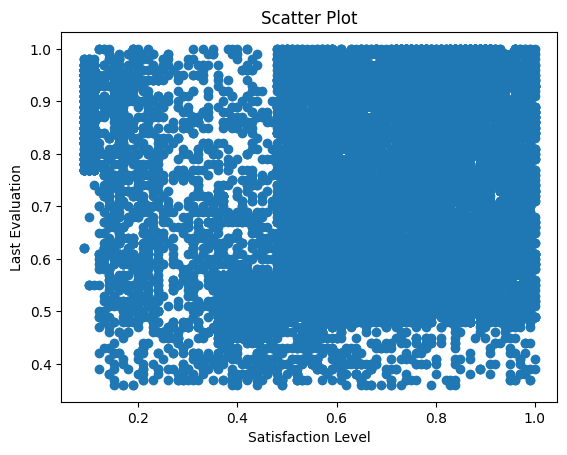

In [ ]:
plt.scatter(df['satisfaction_level'], df['last_evaluation'])
plt.xlabel("Satisfaction Level")
plt.ylabel("Last Evaluation")
plt.title("Scatter Plot")
plt.show()

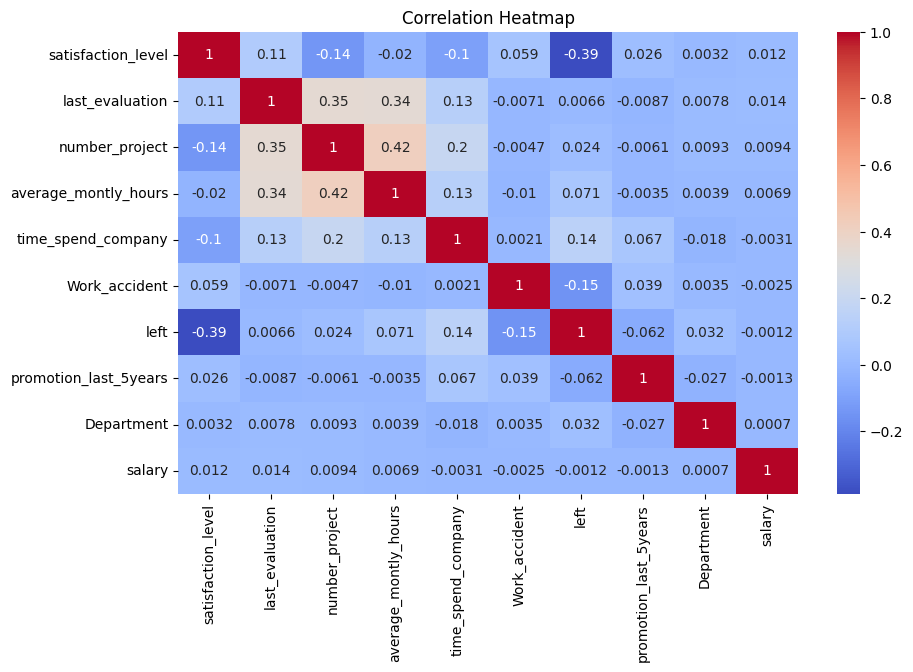

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
from scipy.spatial.distance import euclidean

dist = euclidean(df.iloc[0], df.iloc[1])
print("Euclidean Distance between first two rows:", dist)

Euclidean Distance between first two rows: 105.09179463687924


In [ ]:
from sklearn.model_selection import train_test_split

y = df['left']

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.974324774924975

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      2286
           1       0.96      0.93      0.94       713

    accuracy                           0.97      2999
   macro avg       0.97      0.96      0.96      2999
weighted avg       0.97      0.97      0.97      2999



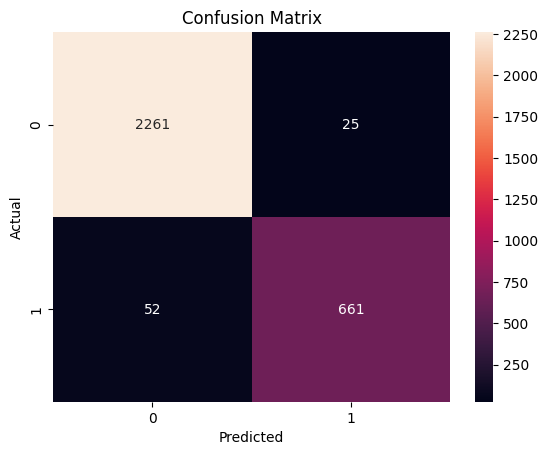

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()